In [2]:
import os
import sys
from pathlib import Path
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from attention import self_attention_torch, positional_encoding
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

TOKEN_TO_IDX = {"X": 0, "O": 1, "_": 2}
RESULT_TO_IDX = {"X": 1, "O": -1, "_": 0}  # for game result
X = "X"
O = "O"
EMPTY = "_"
cwd = Path().resolve().parent.parent

TRAINING_DATA_FILE_PATH = "./data_generation_script/mcts_training_alphazero_data.json"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
device

device(type='cpu')

In [4]:
def load_training_data(file_path):
    if not os.path.exists(file_path):
        raise ValueError("File does not exists")
    with open(file_path, "r") as f:
        data = json.load(f)

    if not data:
        raise ValueError("No data")
    return data


In [5]:
training_data = load_training_data(TRAINING_DATA_FILE_PATH)

batch_zero = training_data[0]
batch_zero

[{'board': ['_', '_', '_', '_', '_', '_', '_', '_', '_'],
  'move': 0,
  'pi': [0.05, 0.1, 0.15, 0.15, 0.1, 0.1, 0.1, 0.15, 0.1],
  'turn': 'X',
  'result': '_'},
 {'board': ['X', '_', '_', '_', '_', '_', '_', '_', '_'],
  'move': 1,
  'pi': [0, 0.05, 0.1, 0.1, 0.1, 0.15, 0.2, 0.15, 0.15],
  'turn': 'O',
  'result': '_'},
 {'board': ['X', 'O', '_', '_', '_', '_', '_', '_', '_'],
  'move': 7,
  'pi': [0, 0, 0.1, 0.25, 0.15, 0.15, 0.1, 0.15, 0.1],
  'turn': 'X',
  'result': '_'},
 {'board': ['X', 'O', '_', '_', '_', '_', '_', 'X', '_'],
  'move': 3,
  'pi': [0, 0, 0.3, 0.15, 0.1, 0.15, 0.15, 0, 0.15],
  'turn': 'O',
  'result': '_'},
 {'board': ['X', 'O', '_', 'O', '_', '_', '_', 'X', '_'],
  'move': 6,
  'pi': [0, 0, 0.25, 0, 0.15, 0.25, 0.2, 0, 0.15],
  'turn': 'X',
  'result': '_'},
 {'board': ['X', 'O', '_', 'O', '_', '_', 'X', 'X', '_'],
  'move': 8,
  'pi': [0, 0, 0.35, 0, 0.15, 0.35, 0, 0, 0.15],
  'turn': 'O',
  'result': '_'},
 {'board': ['X', 'O', '_', 'O', '_', '_', 'X', 'X', 

# Data Preparation

- For training convert them to proper tensor
- Compute z from turn and result for each timestep: +1 if current player won, -1 if lost, 0 if draw.
- Convert all continuous values (pi, z) to float32 to match network output dtype.


In [6]:
for row in training_data:
    for col in row:
        col["board_indices"] = torch.tensor([TOKEN_TO_IDX[val] for val in col["board"]])
        col["result_index"] = torch.tensor(RESULT_TO_IDX[col["result"]])
        col["move"] = torch.tensor(col["move"])

        if col["result"] == col["turn"]:
            col["z"] = torch.tensor(1, dtype=torch.float32)
        elif col["result"] == EMPTY:
            col["z"] = torch.tensor(0, dtype=torch.float32)
        else:
            col["z"] = torch.tensor(-1, dtype=torch.float32)

        col["pi"] = torch.tensor(col["pi"], dtype=torch.float32)
        col["turn"] = torch.tensor(TOKEN_TO_IDX[col["turn"]])

In [7]:
flat_data = []
for game in training_data:
    for move in game:
        flat_data.append(move)

In [8]:
len(flat_data)

6483

In [9]:
# check entropy of training dataset to make sure the pi is suitable


In [10]:
class TTTDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]

In [11]:
max(flat_data[0]['pi'])

tensor(0.1500)

In [12]:
spilt = int(0.8 * len(flat_data))
train_data = flat_data[:spilt]
val_data = flat_data[spilt:]
train_loader = DataLoader(TTTDataset(train_data), batch_size=1, shuffle=True)
val_loader = DataLoader(TTTDataset(val_data), batch_size=1, shuffle=False)

In [13]:
# uncertainity for moves in the given dataset
# meaning the policy loss for the model will never exceed below entropy
# to improve this need to increase the simulation times
# this is how much model should optimize its policy loss
epsilon = 1e-8
pi_lst = torch.stack([item["pi"] for item in flat_data])
entropy = -torch.sum(pi_lst * torch.log(pi_lst + epsilon), dim=1)
entropy.mean()

tensor(1.6311)

In [14]:
# worse possible value loss given by constant predictor
z = torch.stack([item["z"] for item in flat_data])
z_mean = z.mean()
baseline_value_loss = ((z - z_mean) ** 2).mean()
baseline_value_loss


tensor(0.9129)

In [15]:
# true learnable value loss
groups = defaultdict(list)
for item in flat_data:
    groups[tuple(item["board"])].append(item["z"])

avg_z = {board: torch.stack(z).mean() for board, z in groups.items()}
value_loss_floor = torch.cat(
    [(torch.stack(zs) - avg_z[board]) ** 2 for board, zs in groups.items()]
).mean()
value_loss_floor


tensor(0.5117)

In [16]:
# taking small data sample for training so that the model overfits for the data
over_fit_data = [item for item in flat_data if max(item['pi']>0.8)]
over_fit_data = over_fit_data[:10]
over_fit_loader = DataLoader(TTTDataset(over_fit_data), batch_size=1, shuffle=True)

In [17]:
len(over_fit_data)

10

# Model Building


In [18]:
EMBEDDING_DIM = 16  # higher value for proper caputring of dim relationship
SEQ_LENGTH = 9  # board's state for a tic tac toe
VOCAB_SIZE = 3  # 3 possible board states: empty(_), X, O
FFN_HIDDEN_DIM = 32


class AlphaZeroTicTacToeTransformer(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.q_proj = nn.Linear(EMBEDDING_DIM, EMBEDDING_DIM, bias=False)
        self.k_proj = nn.Linear(EMBEDDING_DIM, EMBEDDING_DIM, bias=False)
        self.v_proj = nn.Linear(EMBEDDING_DIM, EMBEDDING_DIM, bias=False)
        self.embeddings = nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM)

        self.ffn_linear1 = nn.Linear(EMBEDDING_DIM, FFN_HIDDEN_DIM)
        self.ffn_linear2 = nn.Linear(FFN_HIDDEN_DIM, EMBEDDING_DIM)

        self.policy_layer = nn.Linear(EMBEDDING_DIM, 1)

        # flatten all 9 positions (9x16=144) into value_layer instead of mean-pooling, so piece signals aren't diluted by empty squares
        self.value_layer = nn.Linear(SEQ_LENGTH * EMBEDDING_DIM, 1)

    def forward(self, x: torch.Tensor):
        x = self.embeddings(x)
        x = x + positional_encoding(x).to(x.dtype)
        # outputs.shape = [seq_length X embed dim]
        # attn_weights.shape = [seq_length X seq_length]
        # outputs= updates embeddings, each pos carries relation info
        # attn_weights carries strength of relationships inbetween every pair pos
        q = self.q_proj(x)  # [9, 16]
        k = self.k_proj(x)
        v = self.v_proj(x)
        attn_out, attn_weights = self_attention_torch(q, k, v)

        # residual around attention
        x = x + attn_out

        hidden_layer = self.ffn_linear1(x)
        hidden_layer = torch.relu(hidden_layer)
        ffn_out = self.ffn_linear2(hidden_layer)

        # residual around FFN
        x = x + ffn_out

        # value head: winning prob given board state (-1 to +1)
        # all position embed_dim is taken into account, prev I was mean pooling which gave equal attention to empty spaces also(not optimal)
        value_pred = x.view(-1)
        value_pred = self.value_layer(value_pred)
        value_pred = torch.tanh(value_pred).squeeze(-1)

        # policy head: possible moves with prob, this is the outputlayer [SEQ_LEGNTH,]
        # return raw logits for now
        policy_logits = self.policy_layer(x)
        policy_log_probs = torch.log_softmax(policy_logits.squeeze(-1), dim=-1)

        # print("attn output shape", outputs.shape)
        # print("attn weights shape", attn_weights.shape)
        return (
            policy_log_probs,
            value_pred,
            attn_weights,
        )

In [19]:
initial_model = AlphaZeroTicTacToeTransformer()
x = torch.tensor([2, 2, 2, 2, 2, 2, 2, 2, 2])
p, v, w = initial_model(x)
p,v 


(tensor([-2.3051, -2.3623, -2.1826, -1.9322, -1.8906, -2.1308, -2.4187, -2.4862,
         -2.2398], grad_fn=<LogSoftmaxBackward0>),
 tensor(-0.1171, grad_fn=<SqueezeBackward1>))

In [20]:
w.std()

tensor(0.0084, grad_fn=<StdBackward0>)

In [21]:
test = AlphaZeroTicTacToeTransformer()
x = torch.tensor([2, 2, 2, 2, 2, 2, 2, 2, 2])
p, v, _ = test(x)
p

tensor([-2.1532, -1.9551, -1.7883, -1.8278, -2.1146, -2.5161, -2.7417, -2.7038,
        -2.5077], grad_fn=<LogSoftmaxBackward0>)

In [22]:
model = AlphaZeroTicTacToeTransformer()
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
value_criterion = nn.MSELoss()


In [23]:
x = torch.tensor([1, 1, 2, 2, 2, 2, 2, 2, 2])
p, v, _ = model(x)
torch.exp(p),v

(tensor([0.2123, 0.1857, 0.0734, 0.0933, 0.1114, 0.1060, 0.0830, 0.0668, 0.0682],
        grad_fn=<ExpBackward0>),
 tensor(-0.8577, grad_fn=<SqueezeBackward1>))

In [24]:
def log_grad_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.norm().item()
        else:
            norms[name] = 0.0  # no gradient reached this parameter at all
    return norms

In [25]:
# train_losses = []
# grad_history = []

# for epoch in range(500):
#     epoch_loss = 0.0
#     grads = None
#     for data in over_fit_loader:
#         x = data["board_indices"].squeeze(0).to(device)  # add batch dimension

#         z = data["z"].to(device)
#         pi = data["pi"].squeeze(0).to(device)

#         optimizer.zero_grad()
#         p, v, _ = model(x)
#         value_loss = value_criterion(v, z.squeeze())
#         policy_loss = -torch.sum(pi * p)

#         loss = value_loss + policy_loss

#         loss.backward()
#         grads = log_grad_norms(model)
#         optimizer.step()

#         epoch_loss += loss.item()  # accumulate batch loss

#     # These lines are **after the inner loop**, still inside epoch loop
#     avg_train_loss = epoch_loss / len(train_loader)
#     if grads is not None:
#         grad_history.append(grads)

#     train_losses.append(avg_train_loss)
#     model.train()

#     print(f"Epoch {epoch + 1} - Training Loss: {avg_train_loss:.4f}")

# Model Training

## Loss Function:

$$l = (z - v)^2 - \pi^\top \log p + c||\theta||^2$$


In [26]:
train_losses = []
val_losses = []
grad_history = []


for epoch in range(100):
    epoch_loss = 0.0
    grads = None
    epoch_policy_loss = 0.0
    epoch_value_loss = 0.0
    for data in train_loader:
        x = data["board_indices"].squeeze(0).to(device)  # add batch dimension

        z = data["z"].to(device)
        pi = data["pi"].squeeze(0).to(device)

        optimizer.zero_grad()
        p, v, _ = model(x)
        value_loss = value_criterion(v, z.squeeze())
        epoch_value_loss += value_loss.item()

        policy_loss = -torch.sum(pi * p)
        epoch_policy_loss += policy_loss.item()

        loss = value_loss + policy_loss

        loss.backward()
        grads = log_grad_norms(model)
        optimizer.step()

        epoch_loss += loss.item()  # accumulate batch loss

    # These lines are **after the inner loop**, still inside epoch loop
    avg_train_loss = epoch_loss / len(train_loader)
    avg_policy_loss = epoch_policy_loss / len(train_loader)
    avg_value_loss = epoch_value_loss / len(train_loader)
    if grads is not None:
        grad_history.append(grads)

    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            x = data["board_indices"].squeeze(0).to(device)
            z = data["z"].to(device)
            pi = data["pi"].squeeze(0).to(device)
            p, v, _ = model(x)
            value_loss = value_criterion(v, z.squeeze())
            policy_loss = -torch.sum(pi * p)

            loss = value_loss + policy_loss
            val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
    model.train()

    print(
        f"Epoch {epoch + 1} - Training Loss: {avg_train_loss:.4f} Validation loss:{avg_val_loss:.4f} Value Loss: {avg_value_loss:.4f} Policy Loss: {avg_policy_loss:.4f}"
    )


Epoch 1 - Training Loss: 2.7852 Validation loss:2.6819 Value Loss: 0.9448 Policy Loss: 1.8403
Epoch 2 - Training Loss: 2.6166 Validation loss:2.6598 Value Loss: 0.8848 Policy Loss: 1.7317
Epoch 3 - Training Loss: 2.6017 Validation loss:2.6197 Value Loss: 0.8709 Policy Loss: 1.7308
Epoch 4 - Training Loss: 2.5891 Validation loss:2.6053 Value Loss: 0.8581 Policy Loss: 1.7310
Epoch 5 - Training Loss: 2.5804 Validation loss:2.6001 Value Loss: 0.8493 Policy Loss: 1.7312
Epoch 6 - Training Loss: 2.5745 Validation loss:2.6025 Value Loss: 0.8436 Policy Loss: 1.7309
Epoch 7 - Training Loss: 2.5686 Validation loss:2.5876 Value Loss: 0.8382 Policy Loss: 1.7304
Epoch 8 - Training Loss: 2.5670 Validation loss:2.5844 Value Loss: 0.8372 Policy Loss: 1.7298
Epoch 9 - Training Loss: 2.5688 Validation loss:2.5869 Value Loss: 0.8395 Policy Loss: 1.7293
Epoch 10 - Training Loss: 2.5698 Validation loss:2.5869 Value Loss: 0.8408 Policy Loss: 1.7290
Epoch 11 - Training Loss: 2.5685 Validation loss:2.5865 Val

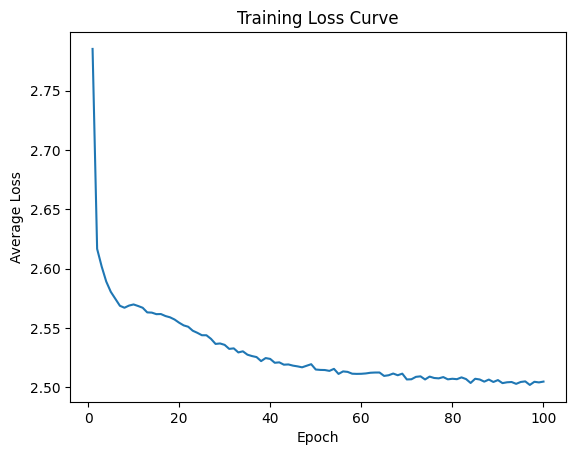

In [27]:
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve")
plt.show()


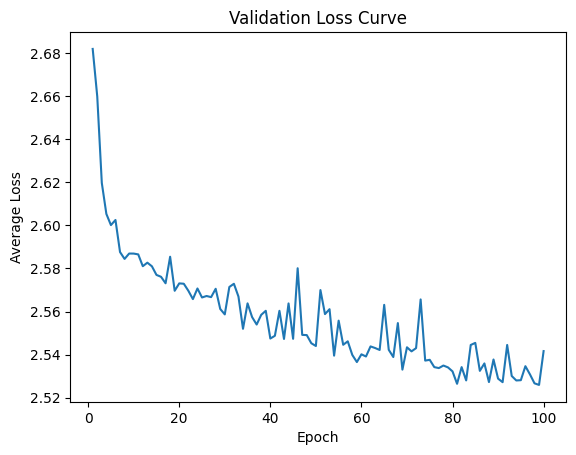

In [28]:
plt.plot(range(1, len(val_losses) + 1), val_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve")
plt.show()

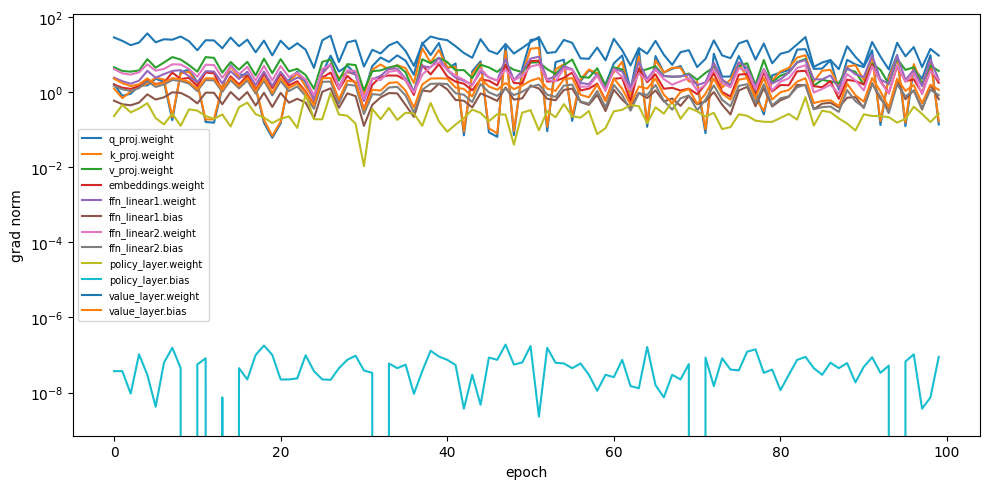

In [29]:
plt.figure(figsize=(10, 5))
for key in grad_history[0]:
    plt.plot([g[key] for g in grad_history], label=key)
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("grad norm")
plt.legend(fontsize=7); plt.tight_layout(); plt.show()

In [30]:
# code for saving model
torch.save(model.state_dict(), "alphazero_tictactoe_2.pth")

# Model Evaluation


In [31]:
model = AlphaZeroTicTacToeTransformer()
model.load_state_dict(torch.load("alphazero_tictactoe_2.pth"))
model.eval()


def predict_move(model, board):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])

    model.eval()
    with torch.no_grad():
        log_probs, value, attn_weights = model(indices)
        # print(log_probs)
    # mask illegal moves (non-empty cells)
    for i, cell in enumerate(board):
        if cell != "_":
            log_probs[i] = float("-inf")

    move = torch.argmax(log_probs).item()
    return move, value, attn_weights


In [32]:
# O about to win - model should block at position 2
board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2 or 5

# X about to win - model should play position 2
board = ["X", "X", "_", "O", "O", "_", "_", "_", "_"]
print(predict_move(model, board))  # should return 2

(8, tensor(0.5841), tensor([[0.0363, 0.0261, 0.0055, 0.3766, 0.4974, 0.0106, 0.0140, 0.0160, 0.0176],
        [0.0466, 0.0316, 0.0053, 0.3666, 0.4923, 0.0106, 0.0138, 0.0157, 0.0175],
        [0.2272, 0.1975, 0.0730, 0.0819, 0.0852, 0.0786, 0.0812, 0.0842, 0.0912],
        [0.1865, 0.1695, 0.0650, 0.1449, 0.1524, 0.0718, 0.0681, 0.0675, 0.0743],
        [0.1811, 0.1651, 0.0543, 0.1758, 0.1866, 0.0611, 0.0572, 0.0562, 0.0626],
        [0.2369, 0.2064, 0.0501, 0.1330, 0.1417, 0.0564, 0.0560, 0.0565, 0.0631],
        [0.2395, 0.2153, 0.0535, 0.1230, 0.1295, 0.0588, 0.0578, 0.0581, 0.0646],
        [0.2398, 0.2220, 0.0643, 0.1016, 0.1039, 0.0662, 0.0652, 0.0655, 0.0716],
        [0.2267, 0.2143, 0.0781, 0.0908, 0.0894, 0.0734, 0.0733, 0.0745, 0.0796]]))
(7, tensor(0.1822), tensor([[0.1153, 0.1193, 0.0891, 0.1477, 0.1494, 0.0931, 0.0918, 0.0943, 0.1002],
        [0.1156, 0.1128, 0.0821, 0.1647, 0.1694, 0.0881, 0.0858, 0.0873, 0.0943],
        [0.1082, 0.0941, 0.0755, 0.1840, 0.1915, 0.0813,

ValueError: too many values to unpack (expected 2)

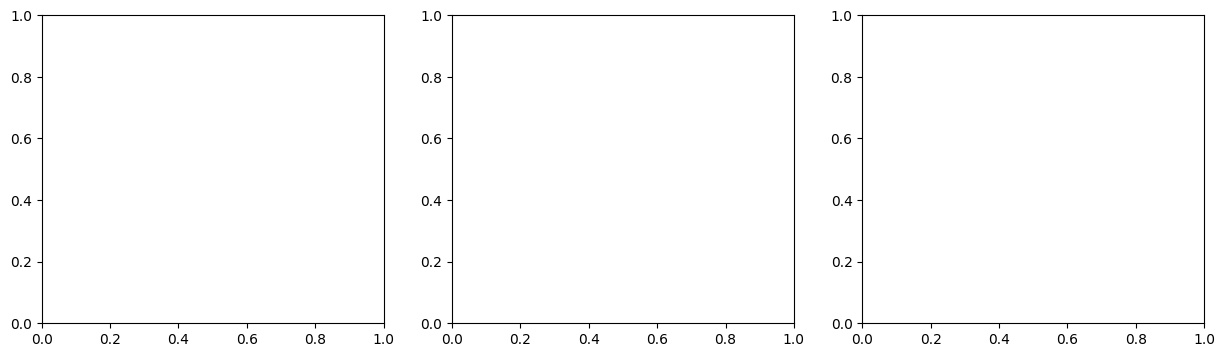

In [33]:
boards = {
    "empty": ["_", "_", "_", "_", "_", "_", "_", "_", "_"],
    "X about to win": ["X", "X", "_", "O", "O", "_", "_", "_", "_"],
    "midgame": ["X", "O", "_", "_", "X", "O", "_", "_", "_"],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, board) in zip(axes, boards.items()):
    indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])
    model.eval()
    with torch.no_grad():
        logits, weights = model(indices)

    weight_matrix = weights
    cell_labels = [f"{s} ({i})" for i, s in enumerate(board)]

    im = ax.imshow(weight_matrix, cmap="hot")
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_xticklabels(cell_labels, fontsize=8)
    ax.set_yticklabels(cell_labels, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
import random
from data_generation_script.uct_mcts import MCTSNode
from data_generation_script.tic_tac_toe import Tictactoe
from copy import deepcopy


mcts_agent = X
ai_agent = O

print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results = {"X": 0, "O": 0, "draw": 0}
for _ in range(100):
    game = Tictactoe()
    while not game.is_gameover():
        if game.turn == ai_agent:
            move, _, _ = predict_move(model, game.board)
            game.make_move(move)
        else:
            root = MCTSNode(state=game)
            mcts_best_move = root.best_action(simulations_number=5)
            # print("===mcts best move===", mcts_best_move)
            game.make_move(mcts_best_move)

    print("\n\nFinal Board:")
    game.print_board()

    if game.winner == game.X:
        results["X"] += 1
        # print("X won!")
    elif game.winner == game.O:
        results["O"] += 1
        # print("O won!")
    else:
        results["draw"] += 1
        # print("Draw!")

mcts_agent: O and ai_agent:X


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
O|O|X
X|X|X
O|X|O


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
O|X|O
O|X|_
_|X|X


Final Board:
_|O|X
_|O|X
O|X|X


Final Board:
X|O|X
O|X|O
O|X|X


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
X|O|O
X|X|O
O|X|X


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
X|O|O
X|X|O
O|X|X


Final Board:
O|O|X
_|O|X
_|X|X


Final Board:
_|O|X
O|_|X
O|X|X


Final Board:
X|O|X
O|X|O
O|X|X


Final Board:
O|X|O
O|X|_
_|X|X


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
O|O|X
X|O|O
X|X|X


Final Board:
X|O|X
O|X|O
O|X|X


Final Board:
X|O|X
X|X|O
O|X|O


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
O|O|X
X|O|X
O|X|X


Final Board:
_|X|O
O|O|_
X|X|X


Final Board:
O|O|X
X|O|O
X|X|X


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
O|O|X
O|X|_
O|X|X


Final Board:
O|X|X
X|X|O
O|X|O


Final Board:
_|X|O
O|X|O
_|X|X


Final Board:
_|_|O
X|X|O
_|X|O


Final Board:
_|_|O
O|X|O
X|X|X


Final Board:

In [53]:
print(f"mcts_agent: {mcts_agent} and ai_agent:{ai_agent}")
results

mcts_agent: O and ai_agent:X


{'X': 91, 'O': 8, 'draw': 1}

In [ ]:
torch.save(model.state_dict(), "tictactoe_transformer_model.pth")

In [ ]:
target_board = ["O", "O", "_", "X", "X", "_", "_", "_", "_"]
for game in training_data:
    for move in game:
        if move["board"] == target_board:
            print(move["pi"])

In [ ]:
print(predict_move(model, ["O", "X", "_", "_", "_", "X", "O", "_", "_"]))

In [ ]:
board = ["O", "X", "_", "_", "_", "X", "O", "_", "_"]
indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])
with torch.no_grad():
    log_probs, value, _ = model(indices)
print(log_probs)
print(value)

In [36]:
empty_board = ["_", "_", "_", "_", "_", "_", "_", "_", "_"]
x_close_win_board = ["X", "X", "_", "_", "_", "_", "_", "_", "_"]
mirrored_of_x_close_win_board = ["_", "X", "X", "_", "_", "_", "_", "_", "_"]


In [ ]:
board = ["O", "X", "_", "_", "_", "X", "O", "_", "_"]
indices = torch.tensor([TOKEN_TO_IDX[s] for s in board])

with torch.no_grad():
    log_probs, value, attn_weights = model(indices)

In [ ]:
value

In [37]:
move, value, attn_weights = predict_move(model=model, board=empty_board)

In [ ]:
move, value

In [ ]:
attn_weights

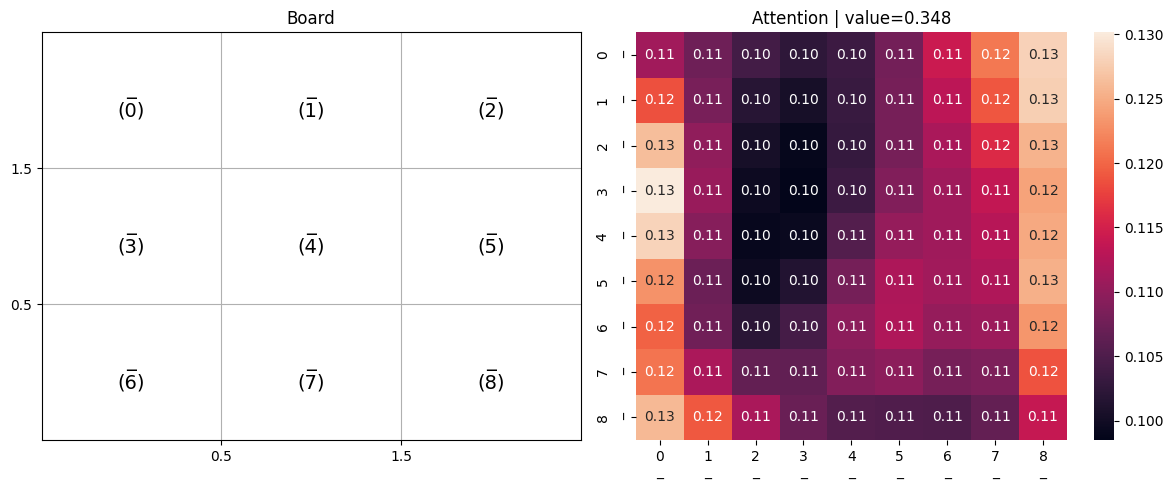

In [38]:
plot_board_attention(empty_board, attn_weights, value)

In [ ]:
value

In [ ]:
_, value, attn_weights = predict_move(model=model, board=x_close_win_board)
plot_board_attention(x_close_win_board, attn_weights, value)

In [35]:
def plot_board_attention(board, attn_weights, value):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    for i in range(3):
        for j in range(3):
            pos = i * 3 + j
            ax.text(
                j,
                2 - i,
                f"{board[pos]}\n({pos})",
                ha="center",
                va="center",
                fontsize=14,
            )
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2.5)
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.grid(True)
    ax.set_title("Board")
    sns.heatmap(
        attn_weights.numpy(),
        annot=True,
        fmt=".2f",
        xticklabels=[f"{i}\n{board[i]}" for i in range(9)],
        yticklabels=[f"{i}\n{board[i]}" for i in range(9)],
        ax=axes[1],
    )
    axes[1].set_title(f"Attention | value={value.item():.3f}")
    plt.tight_layout()
    plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    attn_weights.numpy(),
    annot=True,
    fmt=".2f",
    xticklabels=[f"{i}\n{board[i]}" for i in range(9)],
    yticklabels=[f"{i}\n{board[i]}" for i in range(9)],
)
plt.title(f"Attention Weights | value={value.item():.3f}")
plt.xlabel("Key (attended to)")
plt.ylabel("Query (attending from)")
plt.tight_layout()
plt.show()